In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.feature as cfeature

import plotly.express as px

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut

In [2]:
!ls /g/data/zv2

admin  agcd  catalog


In [3]:
!ls /g/data/zv2/agcd

license.txt  v1-0-1  v1-0-3  v2      v2-0-2  v2-0-4
v1	     v1-0-2  v1-0-4  v2-0-1  v2-0-3


In [4]:
!ls /g/data/zv2/agcd/v2-0-4

precip


In [5]:
from pathlib import Path

In [6]:
AGCD_DIR = Path('/g/data/zv2/agcd/v2-0-4/precip/total/r005/01month/')

In [7]:
AGCD_DIR

PosixPath('/g/data/zv2/agcd/v2-0-4/precip/total/r005/01month')

In [8]:
# list(AGCD_DIR.iterdir())

In [9]:
files = sorted(AGCD_DIR.glob('*.nc'))
# print(files)

In [10]:
agcd = {}

for file in AGCD_DIR.glob('*.nc'):
    year = file.stem[-4:]
    agcd[year] = xr.open_dataset(file)

In [11]:
agcd['1900']

<xarray.Dataset> Size: 29MB
Dimensions:    (lat: 691, nv: 2, lon: 886, time: 12)
Coordinates:
  * lat        (lat) float32 3kB -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon        (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
  * time       (time) datetime64[ns] 96B 1900-01-16 ... 1900-12-16
Dimensions without coordinates: nv
Data variables:
    lat_bnds   (lat, nv) float32 6kB ...
    lon_bnds   (lon, nv) float32 7kB ...
    time_bnds  (time, nv) datetime64[ns] 192B ...
    precip     (time, lat, lon) float32 29MB ...
    crs        int32 4B ...
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1900-01-01T00:00:00
    date_created:              2020-08-27T21:49:15.867624
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2026-05-12 23:28:41
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2026, ...
    history:

In [12]:
# 1d plot check
# precip1d = p1900.isel(lat=10, lon=10)
# precip1d.plot();

In [13]:
agcd['1900']['precip'].min().item()

0.0

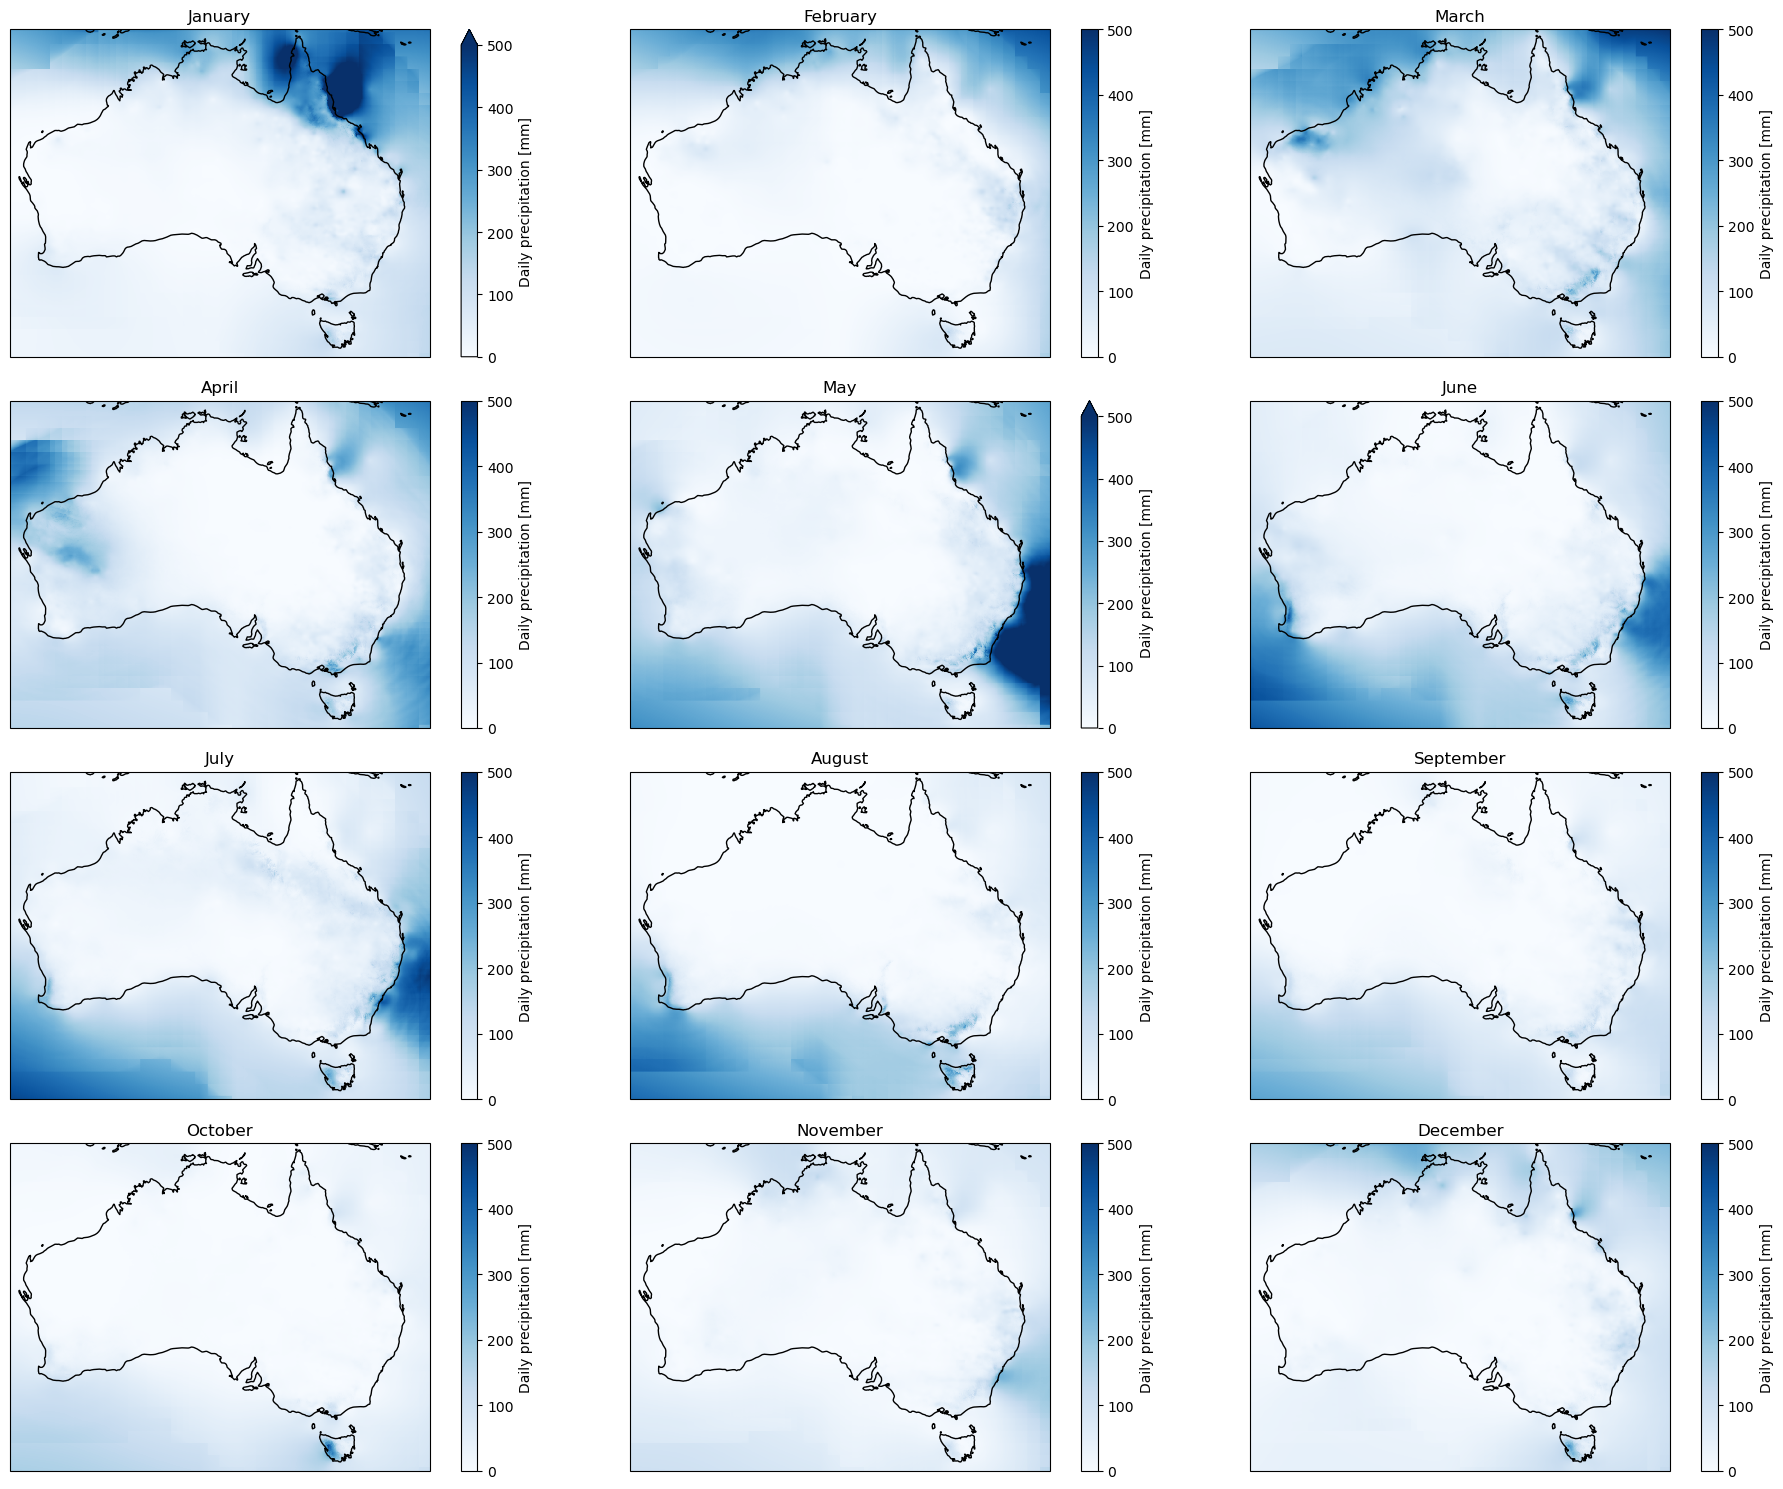

<Figure size 640x480 with 0 Axes>

In [14]:
# test 1900 data 

fig, axes = plt.subplots(
    4, 3,
    figsize=(19, 15),
    subplot_kw={'projection': ccrs.PlateCarree()}
)


for i, ax in enumerate(axes.flat):
    agcd['1900']['precip'].isel(time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='Blues',
        vmin = 0,
        vmax = 500,
        add_colorbar=True
    )
    
    ax.coastlines()
    # ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    # ax.set_extent([110, 155, -45, -10])

    month = agcd['1900']['precip'].time.isel(time=i).dt.strftime('%B').item()
    ax.set_title(month)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

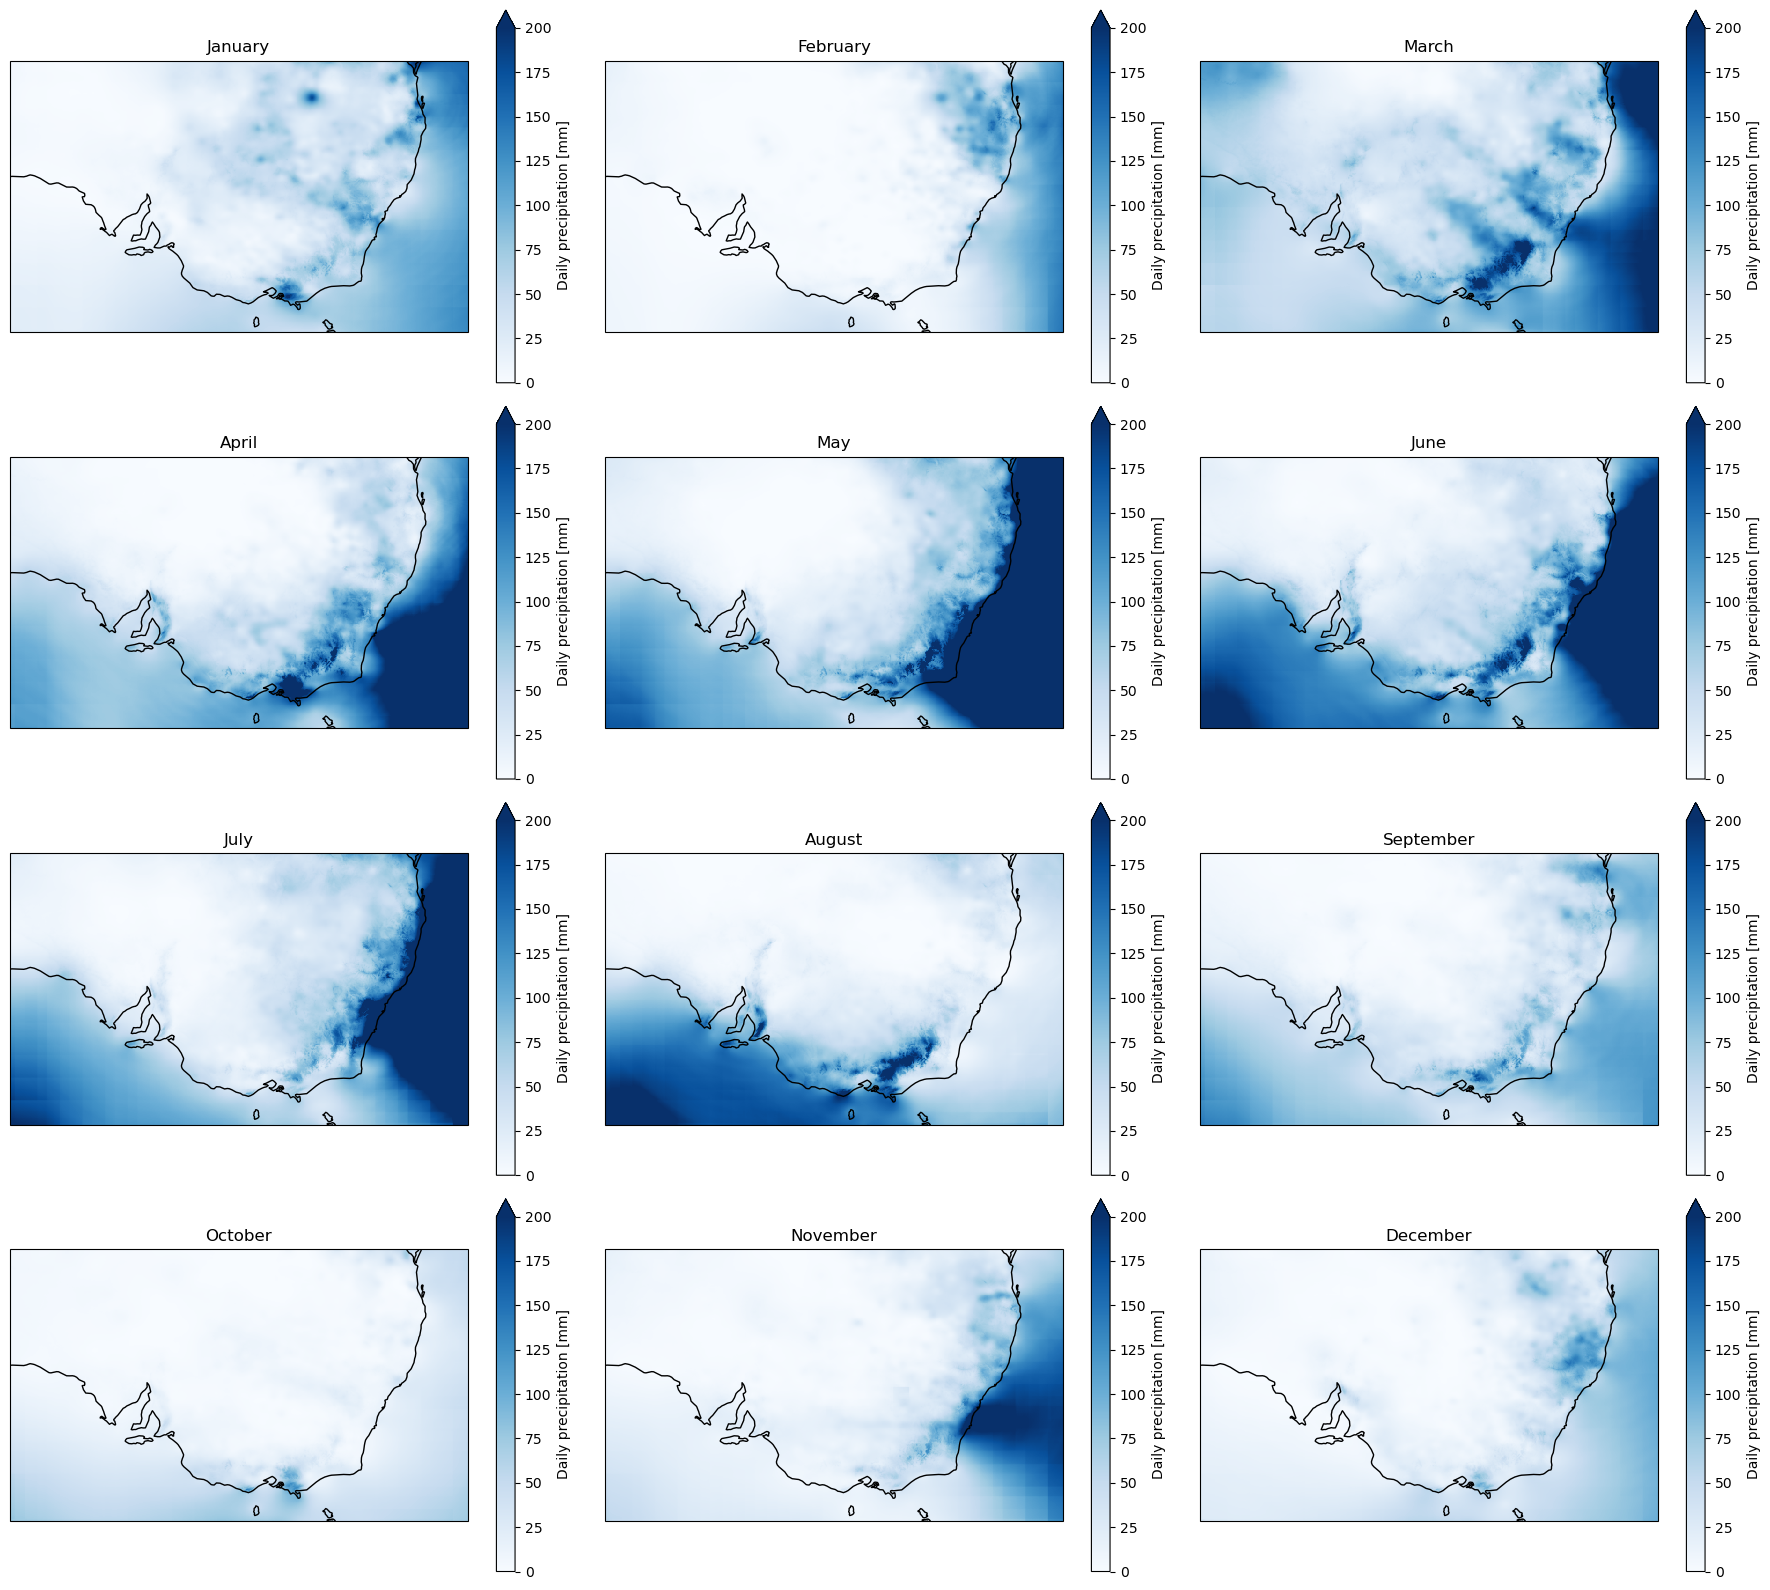

<Figure size 640x480 with 0 Axes>

In [15]:
# victoria 
fig, axes = plt.subplots(
    4, 3,
    figsize=(18, 16),
    subplot_kw={'projection': ccrs.PlateCarree()}
)


for i, ax in enumerate(axes.flat):
    agcd['1900']['precip'].isel(time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='Blues',
        vmin = 0,
        vmax = 200,
        add_colorbar=True
    )
    
    ax.coastlines()
    # ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([130, 156, -40, -25])

    month = agcd['1900']['precip'].time.isel(time=i).dt.strftime('%B').item()
    ax.set_title(month)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [16]:
# entire data 
import ipywidgets as widgets
from IPython.display import display

year_slider = widgets.IntSlider(
    min=1900, max=2025, step=1, value=1900,
    description='Year'
)

month_slider = widgets.IntSlider(
    min=1, max=12, step=1, value=1,
    description='Month'
)

def plot_precip(year, month):
    ds = agcd[str(year)]

    fig, ax = plt.subplots(
        figsize=(10, 7),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    ds['precip'].isel(time=month-1).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='GnBu',
        levels=[0, 10, 25, 50, 100, 200, 300, 500, 750, 1000, 1500]
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    # ax.set_extent([110, 155, -45, -10])
    ax.set_title(f'AGCD precipitation — {year}, month {month}')

    plt.show()

widgets.interact(
    plot_precip,
    year=year_slider,
    month=month_slider
);

interactive(children=(IntSlider(value=1900, description='Year', max=2025, min=1900), IntSlider(value=1, descri…

/jobfs/178704901.gadi-pbs/ipykernel_1096361/3577687807.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine='by_coords')


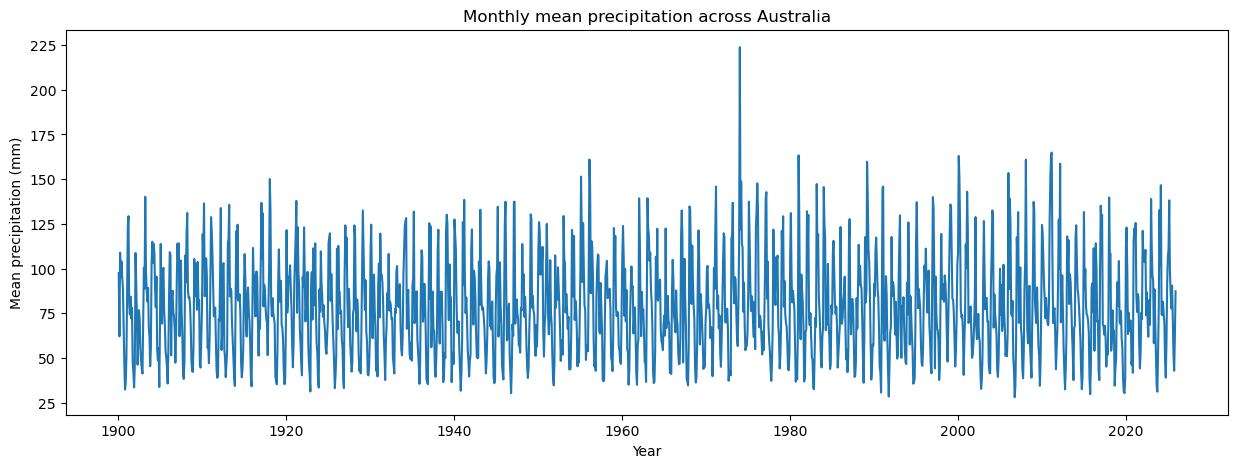

In [17]:
# Rainfall time series (averaged over entire Australia) 

ds = xr.open_mfdataset(files, combine='by_coords')

pmean = ds['precip'].mean(dim=['lat', 'lon'])

pmean.plot(figsize=(15, 5))
plt.ylabel('Mean precipitation (mm)')
plt.xlabel('Year')
plt.title('Monthly mean precipitation across Australia')
plt.show()

In [18]:
# # climatology map 

# all_data = xr.concat(
#     [agcd[str(year)] for year in range(1900, 2026)],
#     dim='time'
# )


# all data

In [11]:
# climatology map 2 (less memory required)
all_data = xr.open_mfdataset(
    files,
    combine='by_coords'
)

climatology = (
    all_data['precip']
    .groupby('time.month')
    .mean('time')
    .compute()
)

# climatology

/jobfs/178707396.gadi-pbs/ipykernel_877977/1154235613.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  all_data = xr.open_mfdataset(


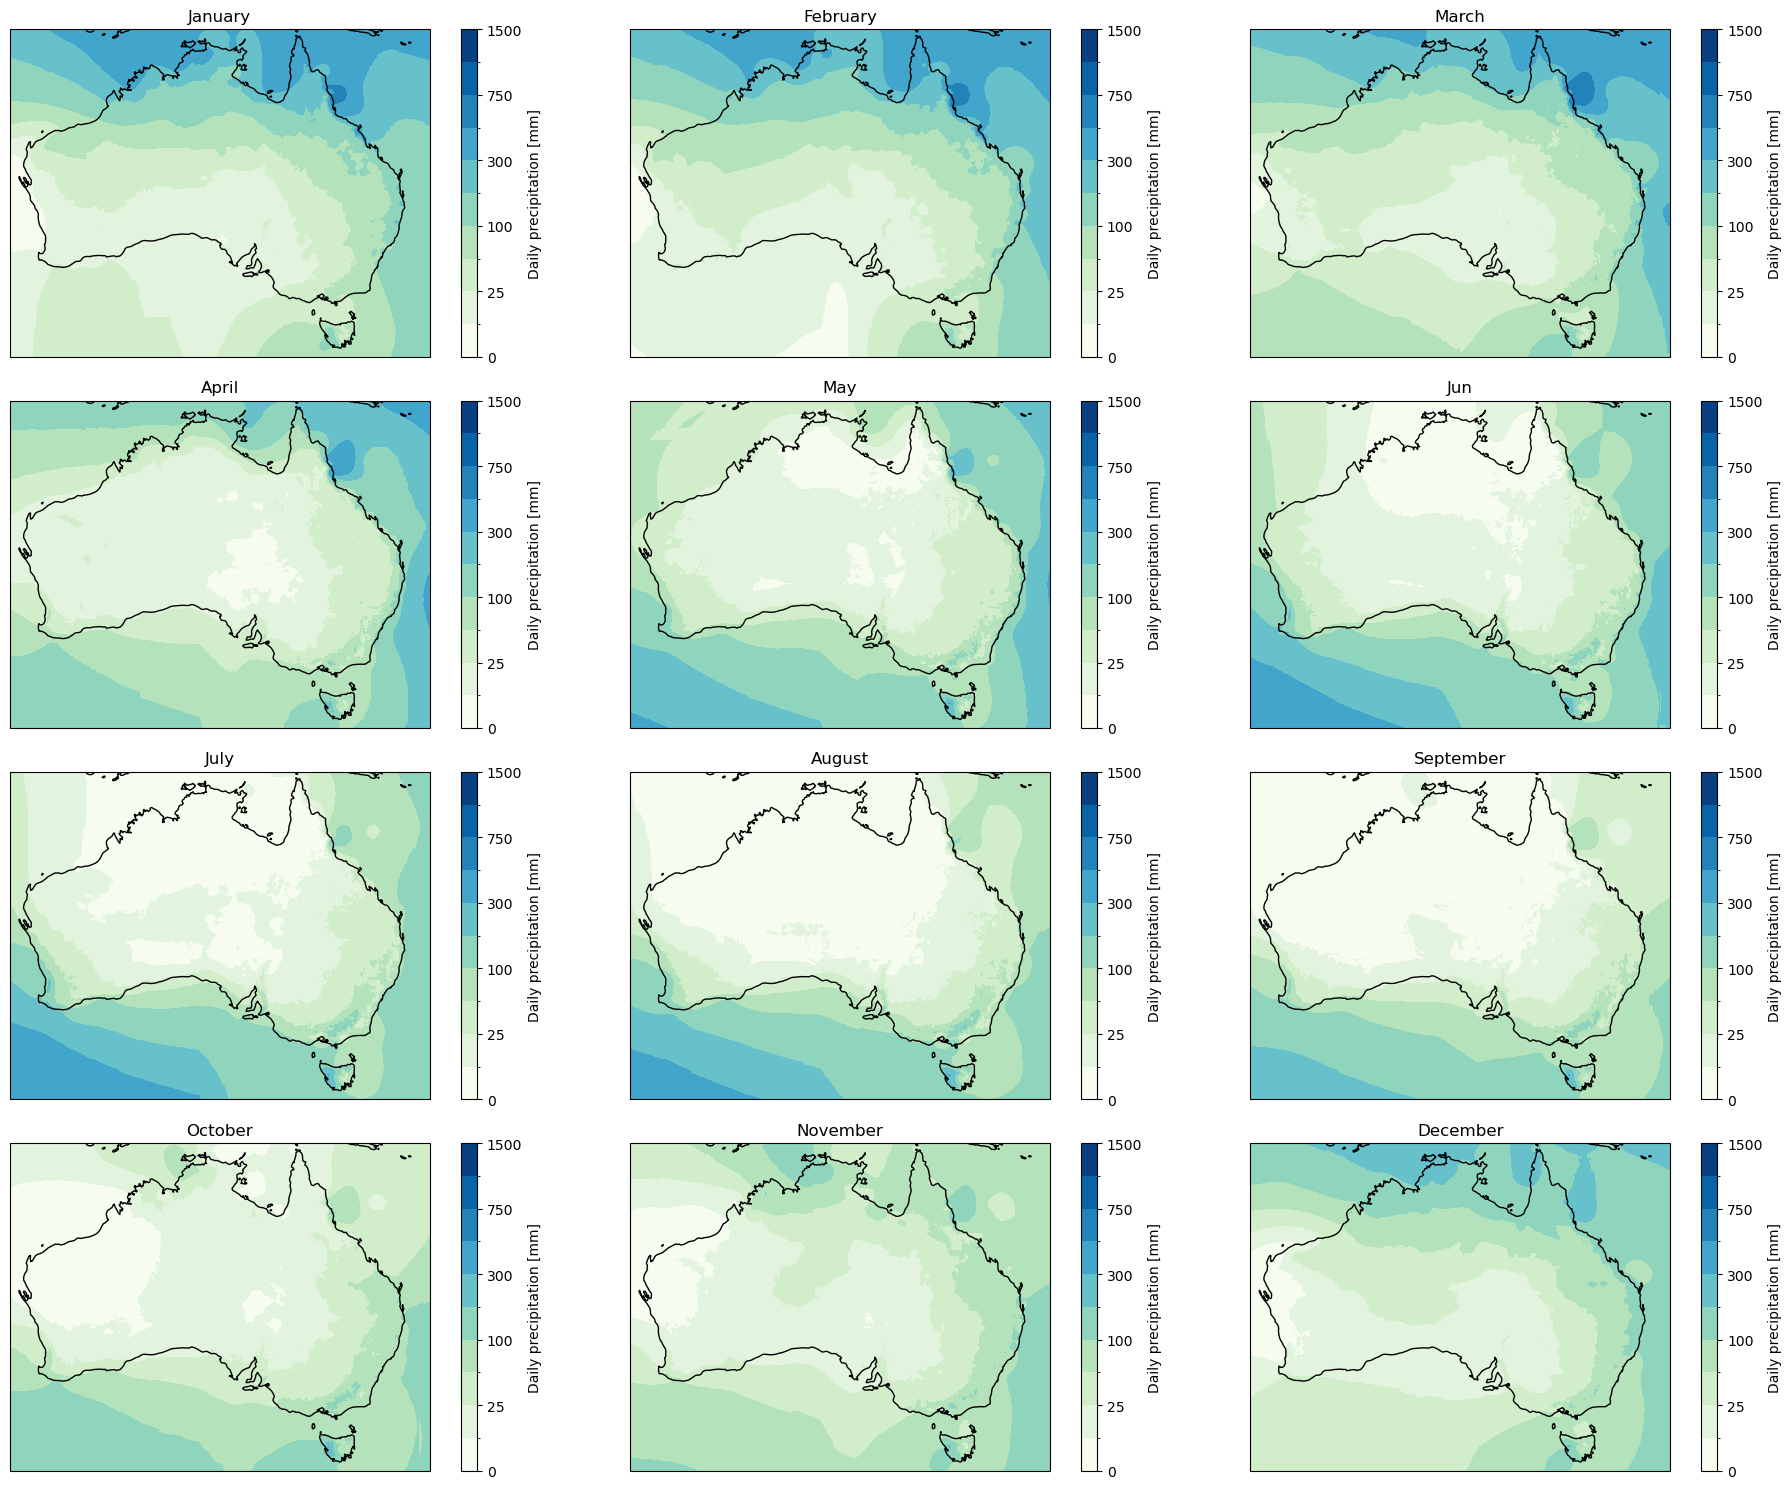

<Figure size 640x480 with 0 Axes>

In [20]:
# plot climatology data 

month = ['January', 'February', 'March', 'April', 'May', 'Jun', 'July', 'August', 'September', 'October', 'November', 'December'] 

fig, axes = plt.subplots(
    4, 3,
    figsize=(19, 15),
    subplot_kw={'projection': ccrs.PlateCarree()}
)


for i, ax in enumerate(axes.flat):
    climatology.isel(month=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='GnBu',
        levels=[0, 10, 25, 50, 100, 200, 300, 500, 750, 1000, 1500],
        # vmin = 0,
        # vmax = 500,
        add_colorbar=True
    )
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    # ax.set_extent([110, 155, -45, -10])

    # month = climatology.month.isel(month=i).item()
    ax.set_title(month[i])

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [21]:
climatology.shape

(12, 691, 886)

In [22]:
print(all_data['precip'].shape)

(1512, 691, 886)


In [12]:
# base climatology 1991-2020

base_climatology = (
    all_data['precip']
    .sel(time=slice('1991', '2020'))
    .groupby('time.month')
    .mean('time')
    .compute()
)

base_climatology.shape

(12, 691, 886)

In [13]:
# anomalies

anomalies = (
    all_data['precip'].groupby('time.month') - base_climatology
).compute()

anomalies.shape

(1512, 691, 886)

Text(0, 0.5, 'Monthly rainfall anomalies (Base: 1900-2025)')

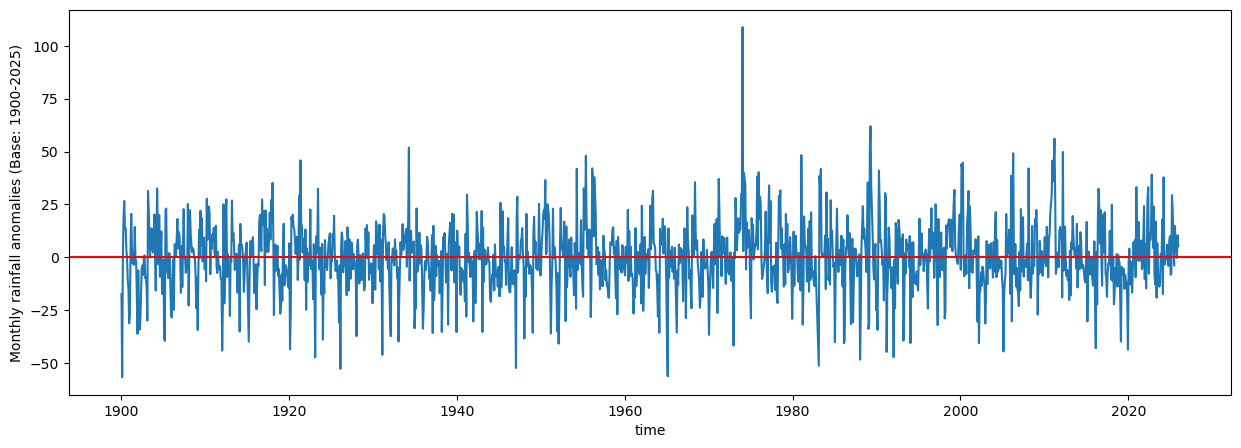

In [25]:
# plot anomalies data 

pmean_anomaly = anomalies.mean(dim=['lat', 'lon'])
pmean_anomaly.plot(figsize=(15, 5))
plt.axhline (y = 0, color = 'r')
plt.ylabel ('Monthly rainfall anomalies (Base: 1900-2025)')

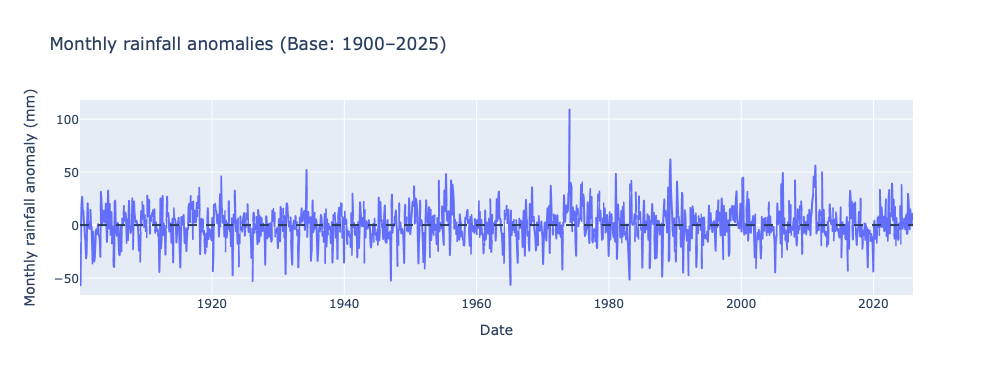

In [26]:
fig = px.line(
    x=pmean_anomaly.time.values,
    y=pmean_anomaly.values,
    labels={
        'x': 'Date',
        'y': 'Monthly rainfall anomaly (mm)'
    },
    title='Monthly rainfall anomalies (Base: 1900–2025)'
)

fig.add_hline(y=0, line_dash='dash')

fig.update_traces(
    hovertemplate='%{x|%B %Y}<br>Anomaly: %{y:.1f} mm<extra></extra>'
)

fig.show()

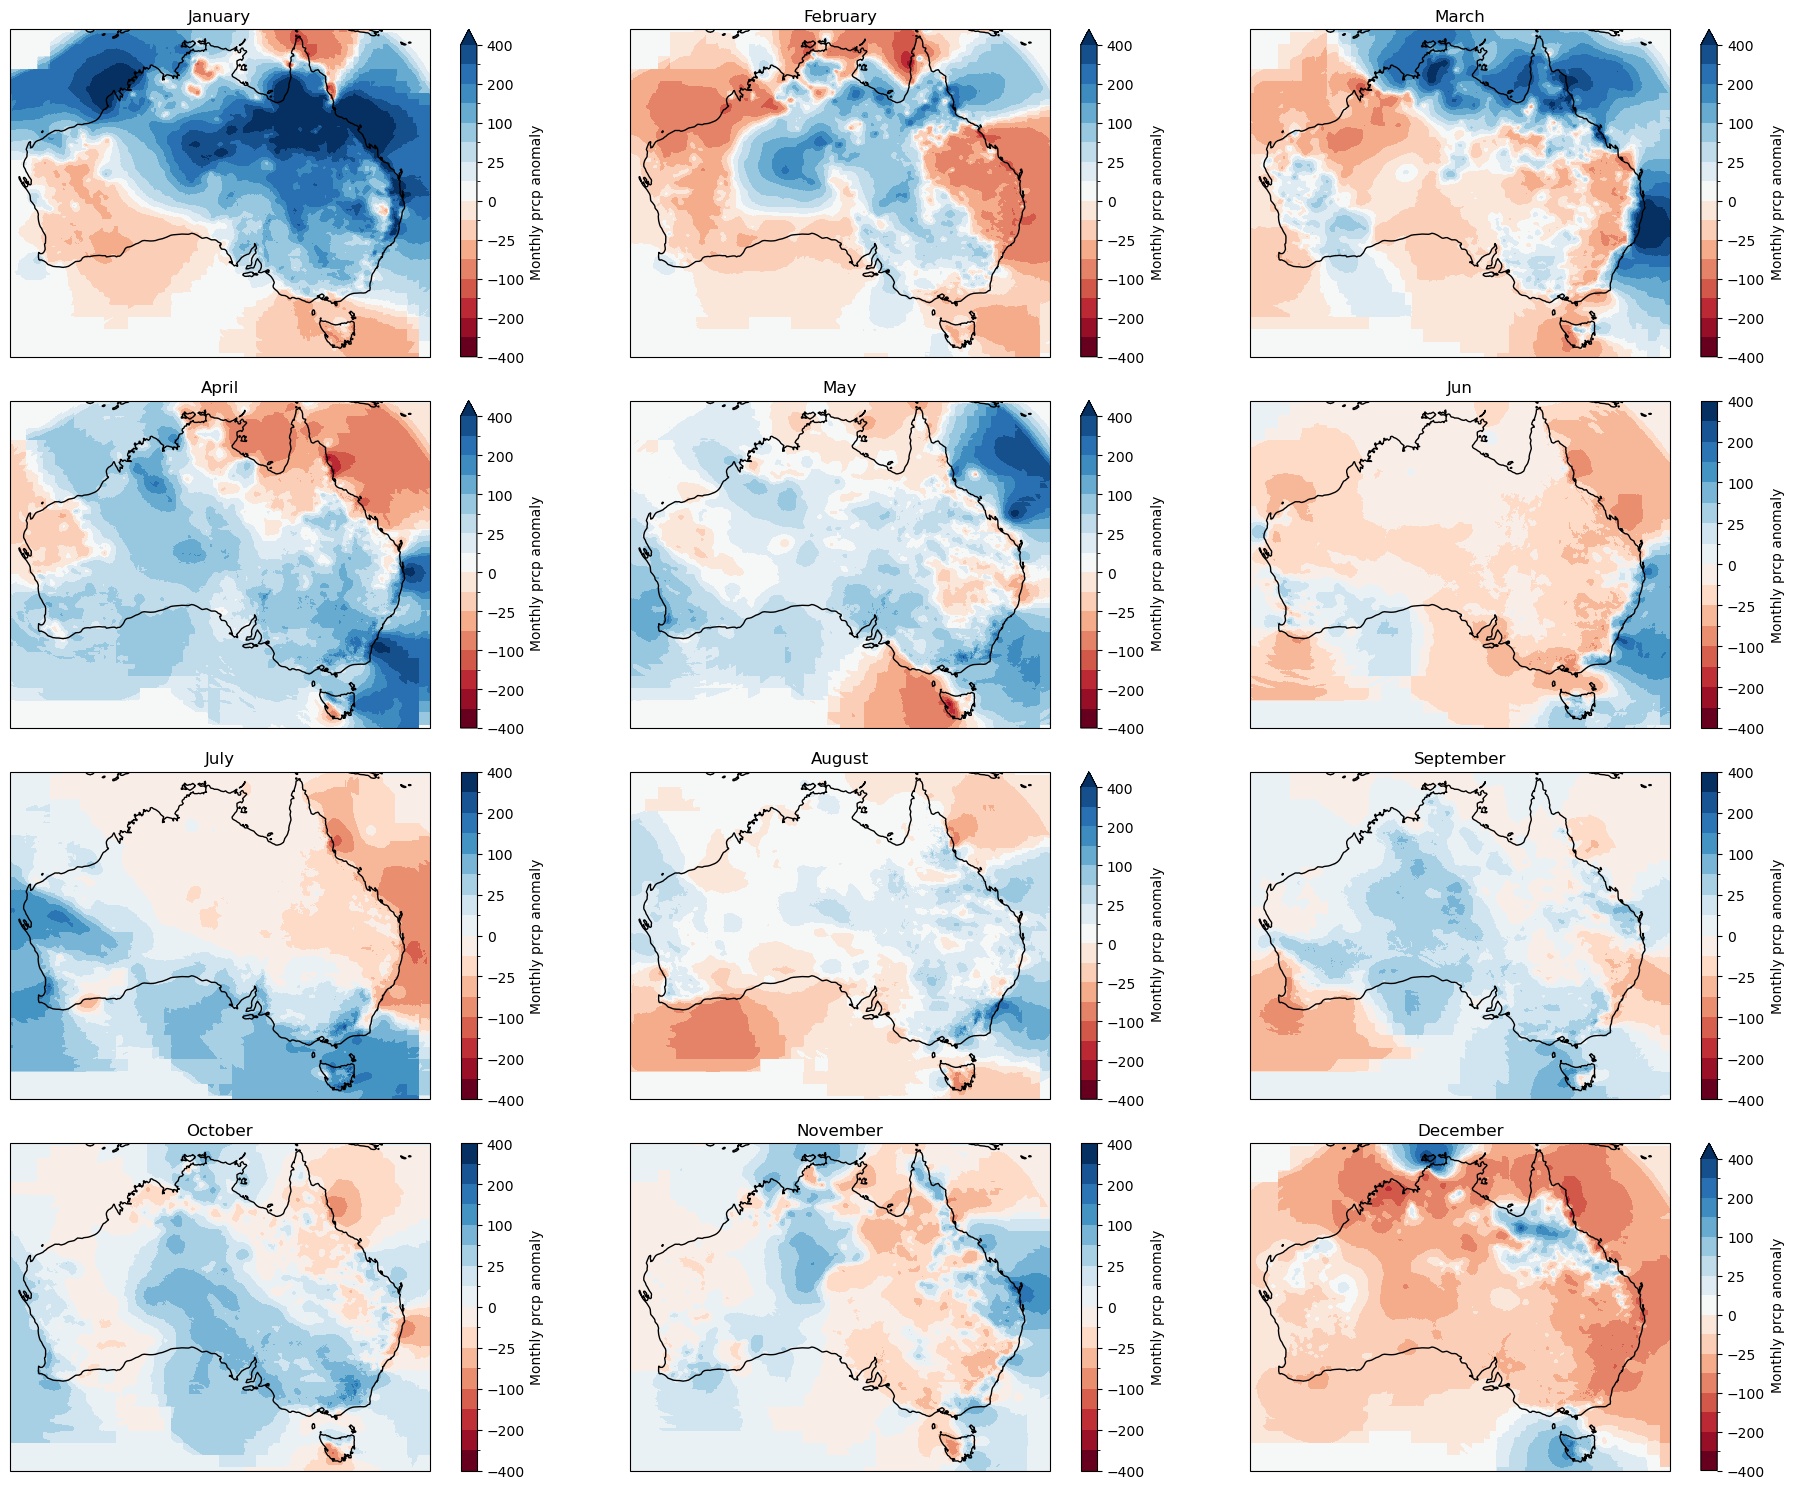

In [27]:
# plot for specific year

anomalies_sp = anomalies.where(anomalies.time.dt.year == 1974, drop=True)

month = ['January', 'February', 'March', 'April', 'May', 'Jun', 'July', 'August', 'September', 'October', 'November', 'December'] 

fig, axes = plt.subplots(
    4, 3,
    figsize=(19, 15),
    subplot_kw={'projection': ccrs.PlateCarree()}
)


for i, ax in enumerate(axes.flat):
    anomalies_sp.isel(time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='RdBu',
        
        levels=[-400,-300,-200,-150,-100,-50,-25,-10 ,0, 10, 25, 50, 100, 150, 200, 300, 400],
        #vmin = -250,
        #vmax = 250,
        add_colorbar=True,
        cbar_kwargs={'label': 'Monthly prcp anomaly'} 
    )
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    # ax.set_extent([110, 155, -45, -10])

    # month = climatology.month.isel(month=i).item()
    ax.set_title(month[i])
    
plt.tight_layout()
plt.show()


In [49]:
# set up LDA 

# potential predictor variable X = oni 
# classification variable t = tercile ranking of the rainfall in subsequent season
# -> discriminant analysis calculates the conditional probability, P(t|X'), of occurrence of class t given a new observation X'
# for each of the three possible classes (above normal, near normal, below normal) 
# (Drosdowsky and Chambers, 2000)


In [50]:
# extract one location (one grid point) 1900-2025
lat = -38
lon = 145
singlegrid = all_data.sel(lat = lat, lon = lon, method = 'nearest') 
singlegrid

singlegrid_series = singlegrid['precip'].to_series()
singlegrid_series

singlegrid_series.to_netcdf('singlegrid_series.nc')

time
1900-01-16 00:00:00     79.341797
1900-02-14 12:00:00     10.788086
1900-03-16 00:00:00    100.931641
1900-04-15 12:00:00    132.331055
1900-05-16 00:00:00     89.133789
                          ...    
2025-08-16 00:00:00     34.117188
2025-09-15 12:00:00     21.872070
2025-10-16 00:00:00     61.302734
2025-11-15 12:00:00    124.903320
2025-12-16 00:00:00     33.585938
Name: precip, Length: 1512, dtype: float32

In [51]:
# oni
oni = xr.open_dataset('~/oni.nc')
oni

oni_series = oni['value'].to_series()
oni_series

time
1950-01-01   -1.53
1950-02-01   -1.34
1950-03-01   -1.16
1950-04-01   -1.18
1950-05-01   -1.07
              ... 
2026-03-01    0.11
2026-04-01    0.46
2026-05-01    0.95
2026-06-01    1.39
2026-07-01    1.80
Name: value, Length: 919, dtype: float32

In [52]:
# roni 
roni = xr.open_dataset('~/roni.nc')
roni

roni_series = roni['value'].to_series()
roni_series

time
1949-01-01     NaN
1949-02-01     NaN
1949-03-01     NaN
1949-04-01     NaN
1949-05-01     NaN
              ... 
2026-04-01   -0.13
2026-05-01    0.52
2026-06-01    1.07
2026-07-01    1.33
2026-08-01    1.67
Name: value, Length: 932, dtype: float32

In [53]:
# extract predictor dataset (oni & roni)  
def get_oni_season(predictor_series, centre_month, year_offset=0):
    """Extract predictor values for seasons centered on a given month, relabeled by target year."""
    sub = oni_series[oni_series.index.month == centre_month].copy()
    sub.index = sub.index.year + year_offset # _.year 
    return sub

In [54]:
# # forecasting 1-month lead
# oni_ndj = get_oni_season (oni_series, centre_month = 12, year_offset = 1) # MAM following year 
# oni_fma = get_oni_season (oni_series, centre_month = 3, year_offset = 0) # JJA
# oni_mjj = get_oni_season (oni_series, centre_month = 6, year_offset = 0) # SON
# oni_aso = get_oni_season (oni_series, centre_month = 9, year_offset = 0) # DJF

# roni_ndj = get_oni_season (roni_series, centre_month = 12, year_offset = 1) # MAM following year 
# roni_fma = get_oni_season (roni_series, centre_month = 3, year_offset = 0) # JJA
# roni_mjj = get_oni_season (roni_series, centre_month = 6, year_offset = 0) # SON
# roni_aso = get_oni_season (roni_series, centre_month = 9, year_offset = 0) # DJF


In [55]:
# # forecasting with 3-month lead

# oni_son = get_oni_season(oni_series, centre_month=10, year_offset=1) # MAM
# oni_djf = get_oni_season(oni_series, centre_month= 1, year_offset=0) # JJA
# oni_mam = get_oni_season (oni_series, centre_month = 4, year_offset = 0) # SON
# oni_jja = get_oni_season (oni_series, centre_month = 7, year_offset = 1) # DJF

# roni_son = get_oni_season(roni_series, centre_month=10, year_offset=1) # MAM
# roni_djf = get_oni_season(roni_series, centre_month= 1, year_offset=0) # JJA
# roni_mam = get_oni_season (roni_series, centre_month = 4, year_offset = 0) # SON
# roni_jja = get_oni_season (roni_series, centre_month = 7, year_offset = 1) # DJF

In [56]:
# oni_ndj.loc[1998]
# roni_ndj.loc[1998]

In [57]:
# build non-overlapping rainfall seasons to start with, later maybe rolling season 

def seasonal_total(rain_series, season_months, year_offset=0):
    """season_months e.g. [3,4,5] for MAM. Handles DJF (crosses year boundary)
    automatically via year_offset if season_months=[12,1,2]."""
    sub = rain_series[rain_series.index.month.isin(season_months)].copy()
    
    if season_months == [12, 1, 2]:
        yr = sub.index.year.where(sub.index.month != 12, sub.index.year + 1) # if not 12, keet index year, if 12 add +1
    else:
        yr = sub.index.year
    
    total = sub.groupby(yr).sum() # total rainfall for 3 months
    counts = sub.groupby(yr).size() # number of months 
    total = total[counts == len(season_months)]  # keep only complete seasons, i.e. 3 months 
    total.index = total.index + year_offset
    return total


In [58]:
# rain_mam = seasonal_total(singlegrid_series, [3,4,5])
# rain_jja = seasonal_total(singlegrid_series, [6,7,8])
# rain_son = seasonal_total(singlegrid_series, [9,10,11])
# rain_djf = seasonal_total(singlegrid_series, [12,1,2])

In [59]:
# define Leave-One-Out-Cross_Validation function 
# For every observation, temporarily hide it, 
# use all the other observations to define the rainfall categories and train LDA, then predict the hidden observation.

def loocv_lda(X, rain_values): # X is predictor data 
    loo = LeaveOneOut() 
    n = len(rain_values) 
    preds = np.zeros(n, dtype=int) # stores LDA's predicted rainfall category for each year (below, near, above normal) 
    probs_all = np.zeros((n, 3)) # stores assigned probability LDA assigns to each category (adds up to 1) 
    obs_tercile = np.zeros(n, dtype=int) # stores actual observed rainfall category for each year 

    for train_idx, test_idx in loo.split(X): # generates training and testing indices from X predictor 
        q33, q67 = np.quantile(rain_values[train_idx], [1/3, 2/3]) # calculates 33rd and 67th percentiles using training data

        y_train = np.digitize(rain_values[train_idx], [q33, q67]) # converts rainfall data to catogories 0,1,2
        y_test  = np.digitize(rain_values[test_idx],  [q33, q67]) # does same for test data 

        lda_cv = LinearDiscriminantAnalysis() # creates LDA classifer: given predictor X, which rainfall tercile is most likely?
        lda_cv.fit(X[train_idx], y_train) # train only with training data 

        preds[test_idx]       = lda_cv.predict(X[test_idx]) # LDA predicts rainfall cateogry of test data 
        probs_all[test_idx]   = lda_cv.predict_proba(X[test_idx]) # LDA predicts probability for each rainfall category 
        obs_tercile[test_idx] = y_test # tells observed/acutal category of test data


    return preds, probs_all, obs_tercile


In [60]:
# Basic skill metrics (Heidke_skill_score -> hit/miss)

def hit_rate(preds, obs):
    return np.mean(preds == obs)

def heidke_skill_score(preds, obs, n_classes=3):
    n = len(obs)
    correct = np.sum(preds == obs)
    expected_correct = n / n_classes
    return (correct - expected_correct) / (n - expected_correct)

In [61]:
# Season / lead-time definitions

season_config = {
    'DJF': {'months': [12,1,2], 'center_1mo': 9,  'offset_1mo': 0, 'center_3mo': 7,  'offset_3mo': 1 }, # double check 
    'MAM': {'months': [3,4,5],  'center_1mo': 12, 'offset_1mo': 1, 'center_3mo': 10, 'offset_3mo': 1},
    'JJA': {'months': [6,7,8],  'center_1mo': 3,  'offset_1mo': 0, 'center_3mo': 1,  'offset_3mo': 0},
    'SON': {'months': [9,10,11],'center_1mo': 6,  'offset_1mo': 0, 'center_3mo': 4,  'offset_3mo': 0},
}

In [62]:
# build dataset and run LOOCV LDA with ONI 1month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(oni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_1mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=75, hit_rate=0.280, HSS=-0.080
MAM: n=75, hit_rate=0.373, HSS=0.060
JJA: n=76, hit_rate=0.382, HSS=0.072
SON: n=76, hit_rate=0.500, HSS=0.250


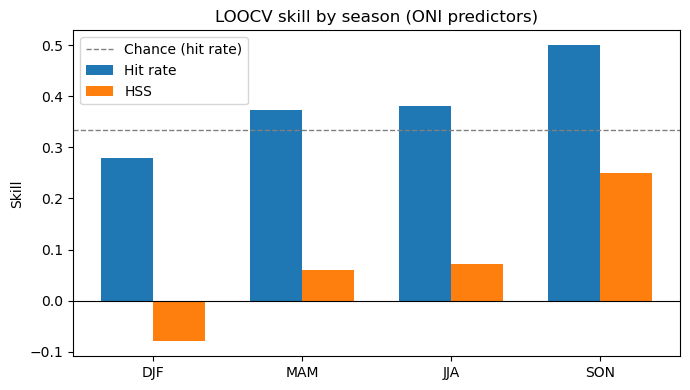

In [63]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season (ONI predictors)')
ax.legend()
plt.tight_layout()
plt.show()

DJF: n=75, hit_rate=0.333, HSS=0.000
MAM: n=75, hit_rate=0.387, HSS=0.080
JJA: n=76, hit_rate=0.434, HSS=0.151
SON: n=76, hit_rate=0.461, HSS=0.191


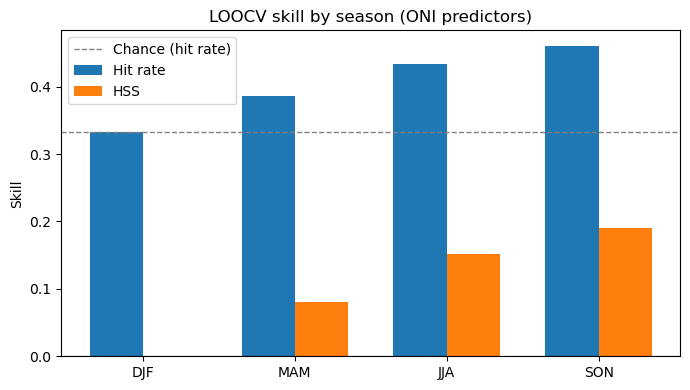

In [64]:
# build dataset and run LOOCV LDA with ONI 3month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(oni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_3mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")


seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season (ONI predictors)')
ax.legend()
plt.tight_layout()
plt.show()
    

In [65]:
def plot_lda_1d(season_name, X_1d, y, ax=None, predictor_label='ONI'):
    """X_1d: shape (n,) or (n,1) - single predictor values
       y: tercile labels (0,1,2)"""
    X_1d = np.asarray(X_1d).reshape(-1, 1)
    
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_1d, y)   # full-data fit, for visualization only - not a skill claim
    
    x_min, x_max = X_1d.min() - 0.5, X_1d.max() + 0.5
    x_grid = np.linspace(x_min, x_max, 500).reshape(-1, 1)
    
    class_pred = lda.predict(x_grid)
    probs = lda.predict_proba(x_grid)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,4))
    
    # background strip showing predicted class region
    colors = ['#4575b4', '#ffffbf', '#d73027']  # below/near/above
    for i in range(len(x_grid)-1):
        ax.axvspan(x_grid[i,0], x_grid[i+1,0], color=colors[class_pred[i]], alpha=0.15, lw=0)
    
    # posterior probability curves
    labels = ['P(Below)', 'P(Near)', 'P(Above)']
    for c in range(3):
        ax.plot(x_grid, probs[:,c], color=colors[c], label=labels[c], linewidth=2)
    
    # actual observed data points, jittered slightly on y for visibility
    for c in range(3):
        mask = y == c
        ax.scatter(X_1d[mask], np.full(mask.sum(), -0.05), color=colors[c], 
                   edgecolor='k', s=40, zorder=5)
    
    # mark decision boundaries (where predicted class changes)
    boundaries = x_grid[:-1][np.diff(class_pred) != 0]
    for b in boundaries:
        ax.axvline(b[0], color='gray', linestyle='--', linewidth=1)
    
    ax.set_xlabel(predictor_label)
    ax.set_ylabel('Posterior probability')
    ax.set_ylim(-0.12, 1.05)
    ax.set_title(f'{season_name}: LDA decision regions ({predictor_label})')
    ax.legend(fontsize=8, loc='upper left')
    return ax



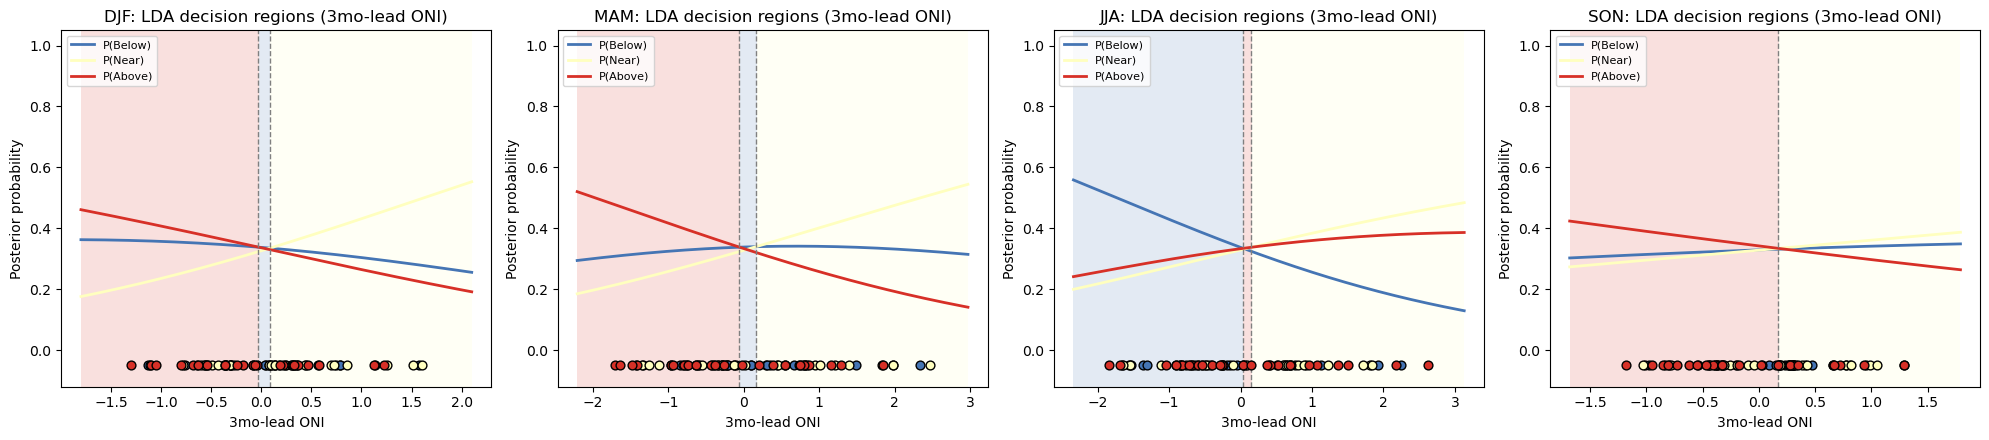

In [66]:
# 3 months oni
fig, axes = plt.subplots(1, 4, figsize=(20,4.5))

for ax, season_name in zip(axes, season_config.keys()):
    cfg = season_config[season_name]
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])
    oni_3mo.name = 'oni_3mo'
    rain.name = 'rain'
    
    df = pd.concat([oni_3mo, rain], axis=1).dropna()
    q33, q67 = df['rain'].quantile([1/3, 2/3])
    df['tercile'] = pd.cut(df['rain'], bins=[-np.inf,q33,q67,np.inf], labels=[0,1,2]).astype(int)
    
    plot_lda_1d(season_name, df['oni_3mo'].values, df['tercile'].values, ax=ax, 
                predictor_label='3mo-lead ONI')

plt.tight_layout()
plt.show()

In [67]:
# build dataset and run LOOCV LDA with RONI 1month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(roni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_1mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=75, hit_rate=0.280, HSS=-0.080
MAM: n=75, hit_rate=0.373, HSS=0.060
JJA: n=76, hit_rate=0.382, HSS=0.072
SON: n=76, hit_rate=0.500, HSS=0.250


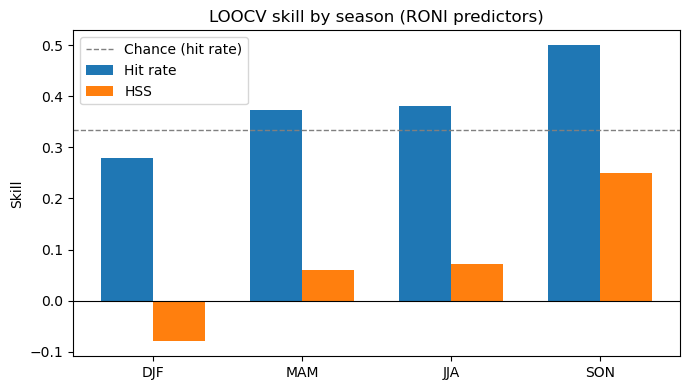

In [68]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season (RONI predictors)')
ax.legend()
plt.tight_layout()
plt.show()
    

In [69]:
# build dataset and run LOOCV LDA with RONI 3month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(roni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_3mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=75, hit_rate=0.333, HSS=0.000
MAM: n=75, hit_rate=0.387, HSS=0.080
JJA: n=76, hit_rate=0.434, HSS=0.151
SON: n=76, hit_rate=0.461, HSS=0.191


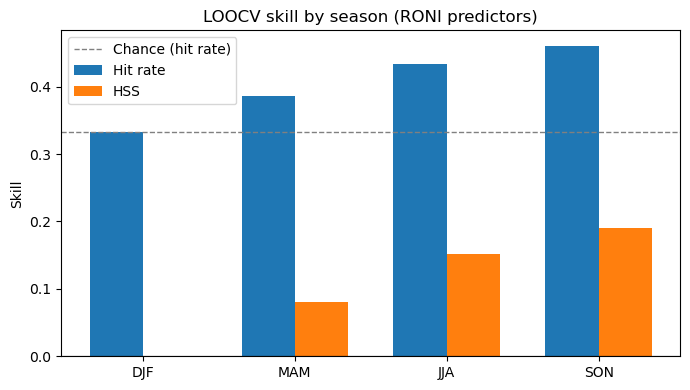

In [70]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season (RONI predictors)')
ax.legend()
plt.tight_layout()
plt.show()

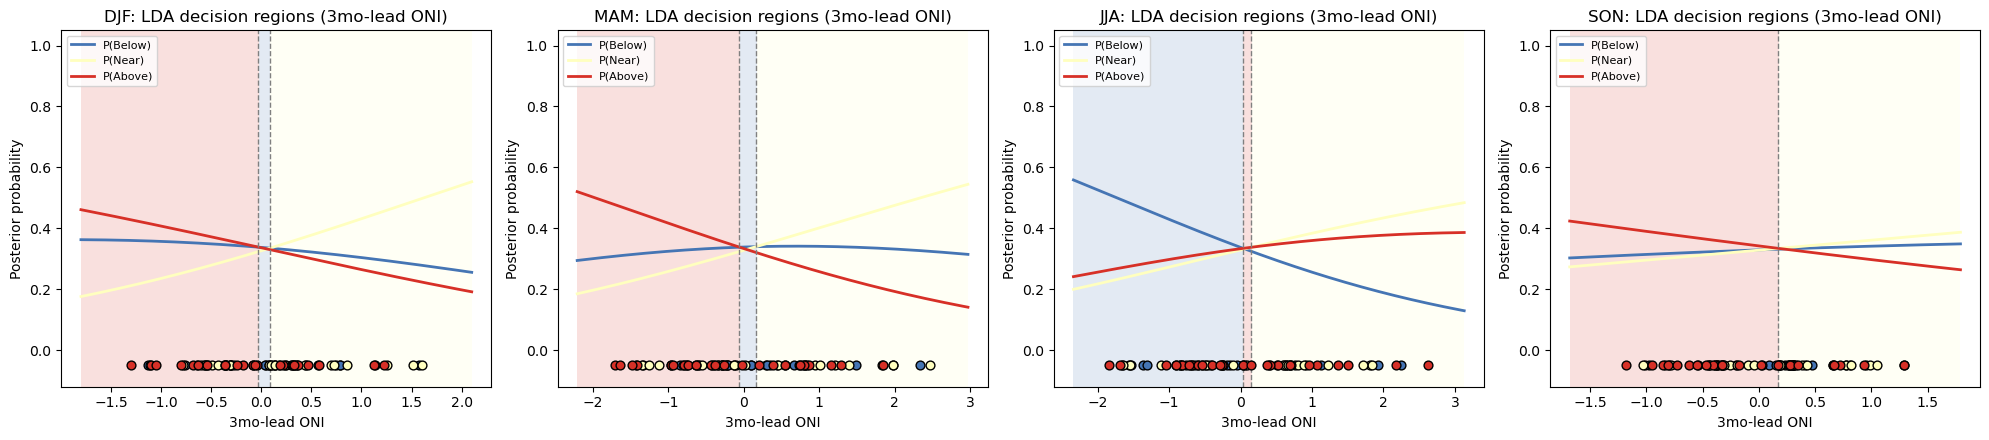

In [71]:
fig, axes = plt.subplots(1, 4, figsize=(20,4.5))

for ax, season_name in zip(axes, season_config.keys()):
    cfg = season_config[season_name]
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])
    oni_3mo.name = 'oni_3mo'
    rain.name = 'rain'
    
    df = pd.concat([oni_3mo, rain], axis=1).dropna()
    q33, q67 = df['rain'].quantile([1/3, 2/3])
    df['tercile'] = pd.cut(df['rain'], bins=[-np.inf,q33,q67,np.inf], labels=[0,1,2]).astype(int)
    
    plot_lda_1d(season_name, df['oni_3mo'].values, df['tercile'].values, ax=ax, 
                predictor_label='3mo-lead ONI')

plt.tight_layout()
plt.show()

In [72]:
# check why exact same oni vs roni
# improving or worsening by time?
# leps

In [73]:
# compare hindcast access - how? leps? 